# DataTour — Baseline v2 (stratégie anti-overfitting temporel)

**Diagnostic v1 :** OOF 0.429 vs public 0.349 → overfitting sur les patterns de comptes du train (target encoding + fréquences qui ne se généralisent pas dans le temps).

**Corrections v2 :**
1. **Validation temporelle** : train sur periods 0-89, val sur 90-105 (≈ test 106-143)
2. **Features robustes** : focus sur signaux transactionnels universels
3. **Target encoding prudent** : smoothing bayésien + poids sur les comptes stables
4. **LightGBM** avec regularisation plus forte
5. **Entraînement final** sur tout le train (0-105)

In [2]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path("dataset")
SEED     = 42

train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Train : {train.shape}  |  Test : {test.shape}")
print(f"Train periods : {train.period.min()} → {train.period.max()}")
print(f"Test  periods : {test.period.min()}  → {test.period.max()}")
print(f"Taux de fraude train : {train['fraud_flag'].mean():.4%}")


Train : (1290081, 11)  |  Test : (430100, 10)
Train periods : 0 → 105
Test  periods : 106  → 143
Taux de fraude train : 10.0414%


## Validation temporelle

Le test est aux périodes 106-143 → on valide sur les dernières périodes du train (90-105) pour simuler le même décalage temporel.

In [3]:
SPLIT_PERIOD = 90   # train: 0-89, val: 90-105

df_tr  = train[train.period <  SPLIT_PERIOD].copy()
df_val = train[train.period >= SPLIT_PERIOD].copy()

print(f"Train   : {len(df_tr):,} lignes  (periods {df_tr.period.min()}-{df_tr.period.max()})")
print(f"Val     : {len(df_val):,} lignes  (periods {df_val.period.min()}-{df_val.period.max()})")
print(f"Fraud tr : {df_tr['fraud_flag'].mean():.4%}  |  Fraud val : {df_val['fraud_flag'].mean():.4%}")


Train   : 1,138,301 lignes  (periods 0-89)
Val     : 151,780 lignes  (periods 90-105)
Fraud tr : 9.6778%  |  Fraud val : 12.7685%


## Feature Engineering

**Stratégie :** distinguer deux types de features :
- **Robustes** (transactionnelles) : fonctionnent sur tout compte, même inconnu
- **Comptables** (historique de compte) : calculées sur le fold d'entraînement uniquement

In [4]:
def build_transactional_features(df):
    df = df.copy()
    eps = 1e-6

    # Operation
    df["is_op03"] = (df["operation"] == "op_03").astype(int)

    # Montant
    df["amount_log"]  = np.log1p(df["amount"])
    df["amount_sqrt"] = np.sqrt(np.maximum(df["amount"], 0))

    # Plage typique fraudes op_03 (19800-560000)
    df["in_fraud_range"] = ((df["amount"] >= 19000) & (df["amount"] <= 600000)).astype(int)
    df["op03_in_range"]  = (df["is_op03"] & df["in_fraud_range"]).astype(int)

    # Variations solde
    df["orig_chg"] = df["origin_balance_after"]      - df["origin_balance_before"]
    df["dest_chg"] = df["destination_balance_after"] - df["destination_balance_before"]

    # Anomalies comptables
    df["orig_no_move"]  = ((df["orig_chg"].abs() < 0.01) & (df["amount"] > 0)).astype(int)
    df["dest_no_move"]  = ((df["dest_chg"].abs() < 0.01) & (df["amount"] > 0)).astype(int)
    df["weird_orig"]    = ((df["orig_chg"] + df["amount"]).abs() > 0.5).astype(int)
    df["weird_dest"]    = ((df["dest_chg"] - df["amount"]).abs() > 0.5).astype(int)
    df["both_weird"]    = (df["weird_orig"] & df["weird_dest"]).astype(int)

    # Ratios
    df["amt_to_orig"]    = df["amount"] / (df["origin_balance_before"].abs()      + eps)
    df["amt_to_dest"]    = df["amount"] / (df["destination_balance_before"].abs() + eps)
    df["orig_chg_ratio"] = df["orig_chg"] / (df["amount"] + eps)
    df["dest_chg_ratio"] = df["dest_chg"] / (df["amount"] + eps)

    # Soldes negatifs
    df["orig_bal_neg"]  = (df["origin_balance_before"] < 0).astype(int)
    df["orig_bal_zero"] = (df["origin_balance_before"].abs() < 1).astype(int)

    # Periode
    df["period_mod10"] = df["period"] % 10
    df["period_div10"] = df["period"] // 10

    return df

df_tr  = build_transactional_features(df_tr)
df_val = build_transactional_features(df_val)
test   = build_transactional_features(test)
train  = build_transactional_features(train)
print("Features transactionnelles construites.")


Features transactionnelles construites.


In [5]:
def build_account_features(df_target, df_source, suffix=""):
    """
    Calcule les features de compte à partir de df_source (jamais de df_target
    pour éviter le leakage).
    """
    df = df_target.copy()
    global_mean = df_source["fraud_flag"].mean()

    # Smoothed target encoding (bayésien)

    # weight = n / (n + k) où k est un hyperparamètre de smoothing
    K = 100  # plus K est grand, plus on régularise vers la moyenne globale

    for col in ["origin_account", "destination_account", "operation"]:
        stats = df_source.groupby(col)["fraud_flag"].agg(["sum", "count"])
        smoothed = (stats["sum"] + K * global_mean) / (stats["count"] + K)
        df[f"{col}_te{suffix}"] = df[col].map(smoothed).fillna(global_mean)

    # Fréquence (normalise par le train source)
    for col in ["origin_account", "destination_account"]:
        freq = df_source[col].value_counts(normalize=True)
        df[f"{col}_freq{suffix}"] = df[col].map(freq).fillna(0)

    # Agrégations comportementales
    orig_agg = df_source.groupby("origin_account").agg(
        orig_n_tx        = ("fraud_flag", "count"),
        orig_n_periods   = ("period",     "nunique"),
        orig_n_dest      = ("destination_account", "nunique"),
        orig_amount_mean = ("amount",     "mean"),
        orig_amount_std  = ("amount",     "std"),
        orig_amount_max  = ("amount",     "max"),
    ).fillna(0)
    orig_agg["orig_amount_std"] = orig_agg["orig_amount_std"].fillna(0)

    dest_agg = df_source.groupby("destination_account").agg(
        dest_n_tx        = ("fraud_flag", "count"),
        dest_n_orig      = ("origin_account",  "nunique"),
        dest_amount_mean = ("amount",     "mean"),
        dest_amount_std  = ("amount",     "std"),
    ).fillna(0)
    dest_agg["dest_amount_std"] = dest_agg["dest_amount_std"].fillna(0)

    df = df.join(orig_agg, on="origin_account")
    df = df.join(dest_agg, on="destination_account")

    # Remplir les inconnus avec 0 / médiane
    agg_cols = list(orig_agg.columns) + list(dest_agg.columns)
    for c in agg_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df_source[c] if c in df_source.columns else 0)

    return df

# Validation temporelle : features de compte calculées sur df_tr seulement
df_val = build_account_features(df_val, df_source=df_tr)
df_tr  = build_account_features(df_tr,  df_source=df_tr)

print(f"Account features construites. Shape train={df_tr.shape}, val={df_val.shape}")


Account features construites. Shape train=(1138301, 46), val=(151780, 46)


In [6]:
TRANSACT_FEATS = [
    "is_op03","in_fraud_range",
    "op03_in_range",
    "amount", "amount_log", "amount_sqrt",
    "origin_balance_before", "origin_balance_after",
    "destination_balance_before", "destination_balance_after",
    "orig_chg", "dest_chg",
    "orig_no_move", "dest_no_move",
    "weird_orig", "weird_dest", "both_weird",
    "amt_to_orig", "amt_to_dest",
    "orig_chg_ratio", "dest_chg_ratio",
    "orig_bal_neg", "orig_bal_zero",
    "period", "period_mod10", "period_div10",
]

ACCOUNT_FEATS = [
    "origin_account_te", "destination_account_te", "operation_te",
    "origin_account_freq", "destination_account_freq",
    "orig_n_tx", "orig_n_periods", "orig_n_dest",
    "orig_amount_mean", "orig_amount_std", "orig_amount_max",
    "dest_n_tx", "dest_n_orig", "dest_amount_mean", "dest_amount_std",
]

FEATURES = TRANSACT_FEATS + ACCOUNT_FEATS
print(f"{len(FEATURES)} features au total.")


41 features au total.


## Entraînement - validation temporelle

In [7]:
LGB_PARAMS = dict(
    objective         = "binary",
    metric            = "average_precision",
    learning_rate     = 0.03,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 100,
    feature_fraction  = 0.7,
    bagging_fraction  = 0.7,
    bagging_freq      = 1,
    lambda_l1         = 1.0,
    lambda_l2         = 1.0,
    min_gain_to_split = 0.01,
    scale_pos_weight  = (df_tr.fraud_flag == 0).sum() / (df_tr.fraud_flag == 1).sum(),
    n_estimators      = 3000,
    random_state      = SEED,
    verbose           = -1,
)

X_tr  = df_tr[FEATURES].fillna(0)
y_tr  = df_tr["fraud_flag"]
X_val = df_val[FEATURES].fillna(0)
y_val = df_val["fraud_flag"]

model_temp = lgb.LGBMClassifier(**LGB_PARAMS)
model_temp.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(200, verbose=False),
        lgb.log_evaluation(200),
    ],
)

val_pred = model_temp.predict_proba(X_val)[:, 1]
temp_ap  = average_precision_score(y_val, val_pred)

print(f"\nPR-AUC validation temporelle (periods 90-105) : {temp_ap:.5f}")
print(f"Best iteration : {model_temp.best_iteration_}")
print(f"(Score public v1 était 0.349 — objectif: dépasser sur le test réel)")


[200]	valid_0's average_precision: 0.362034

PR-AUC validation temporelle (periods 90-105) : 0.36207
Best iteration : 197
(Score public v1 était 0.349 — objectif: dépasser sur le test réel)


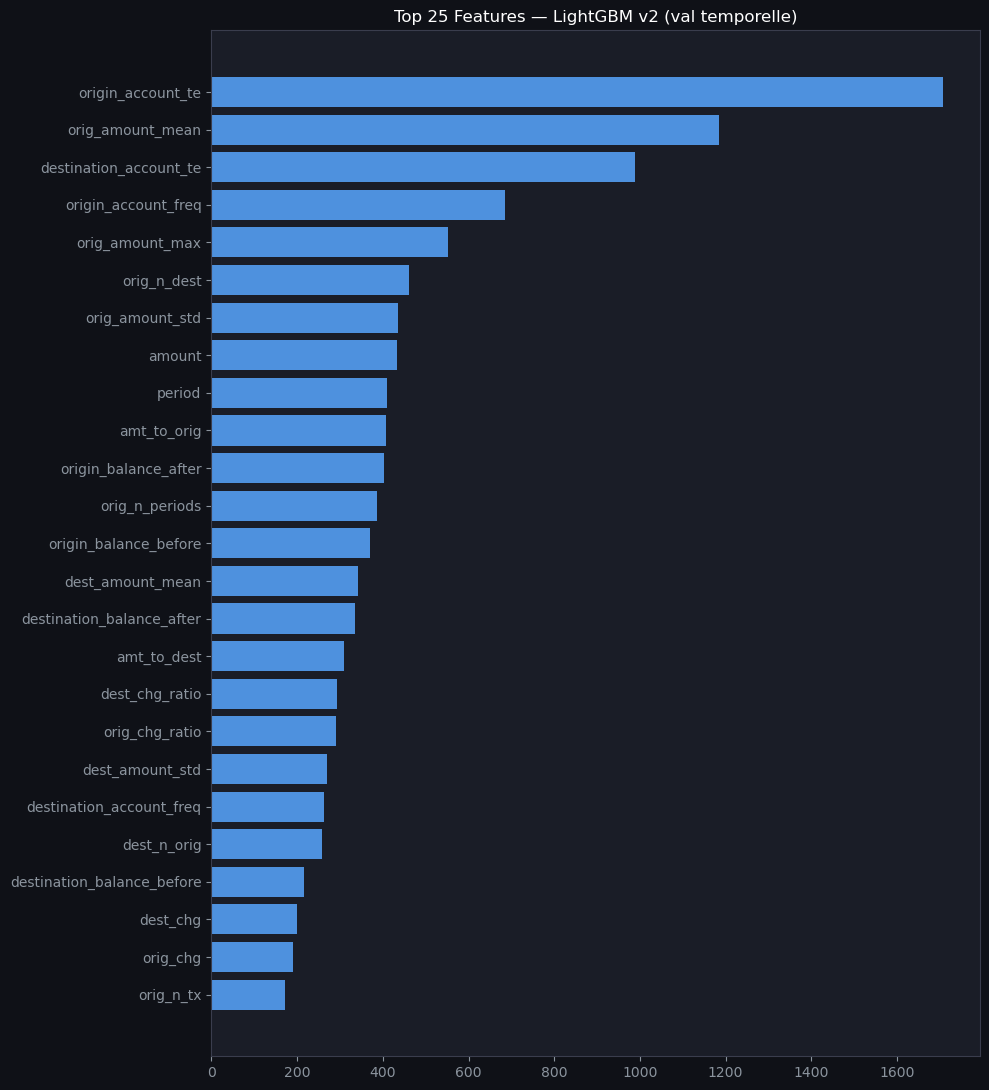

Top 10 features :
               feature  importance
     origin_account_te        1708
      orig_amount_mean        1185
destination_account_te         988
   origin_account_freq         686
       orig_amount_max         551
           orig_n_dest         462
       orig_amount_std         436
                amount         434
                period         409
           amt_to_orig         407


In [7]:
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#3a3d4d",   "axes.labelcolor": "#c9d1d9",
    "xtick.color": "#8b949e",      "ytick.color": "#8b949e",
    "text.color": "#c9d1d9",
})

fi = pd.DataFrame({
    "feature":    FEATURES,
    "importance": model_temp.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 11), facecolor="#0f1117")
ax.barh(fi.feature[:25][::-1], fi.importance[:25][::-1],
        color="#58a6ff", edgecolor="none", alpha=0.85)
ax.set_title("Top 25 Features — LightGBM v2 (val temporelle)", color="white", fontsize=12)
plt.tight_layout()
plt.savefig("eda_plots/09_feat_imp_v2.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Top 10 features :")
print(fi.head(10).to_string(index=False))


## Entraînement final sur tout le train (0-105)

On recalcule les features de compte sur **tout le train** pour maximiser l'information disponible.

In [8]:
# Reconstruction des features de compte sur tout le train
train_full = build_account_features(train, df_source=train)
test_full  = build_account_features(test,  df_source=train)

X_full      = train_full[FEATURES].fillna(0)
y_full      = train_full["fraud_flag"]
X_test_full = test_full[FEATURES].fillna(0)

# Nb d'itérations = best_iteration du modèle temporel (+ marge)
BEST_ITER = model_temp.best_iteration_
print(f"Nombre d'itérations pour entraînement final : {BEST_ITER}")

PARAMS_FINAL = {**LGB_PARAMS}
PARAMS_FINAL["n_estimators"] = BEST_ITER
del PARAMS_FINAL["metric"]  # pas de eval_set

model_final = lgb.LGBMClassifier(**PARAMS_FINAL)
model_final.fit(X_full, y_full)

test_pred = model_final.predict_proba(X_test_full)[:, 1]
test_pred = np.clip(test_pred, 0, 1)

print(f"Prédictions test : min={test_pred.min():.4f}  max={test_pred.max():.4f}  mean={test_pred.mean():.4f}")


Nombre d'itérations pour entraînement final : 197
Prédictions test : min=0.0003  max=0.9973  mean=0.2709


## Génération de la soumission v2

In [10]:
submission = pd.DataFrame({
    "id":     test["id"],
    "target": test_pred,
})

OUT_FILE = "dataset/submission.csv"
submission.to_csv(OUT_FILE, index=False)

# Vérifications
assert submission.shape[0] == test.shape[0]
assert list(submission.columns) == ["id", "target"]
assert submission["id"].is_unique
assert submission["target"].between(0, 1).all()
assert set(submission["id"]) == set(sample_sub["id"])

print(f"{OUT_FILE} généré et valide !")
print(f"   PR-AUC validation temporelle : {temp_ap:.5f}")
print(f"   Score public v1              : 0.349012")
print()
display(submission.head())


dataset/submission.csv généré et valide !
   PR-AUC validation temporelle : 0.36207
   Score public v1              : 0.349012



,id,target
0,dtf_0000001_08a8a524,0.000274
1,dtf_0000002_ae0d3769,0.783757
2,dtf_0000003_843bab7c,0.800030
3,dtf_0000004_91643844,0.000274
4,dtf_0000005_17bd9a08,0.708438


## Diagnostic : Baseline v1 → Score public 0.349 vs OOF 0.429

---

### Problème 1 - Validation trompeuse (le plus grave)

**Baseline v1** utilisait un `StratifiedKFold` aléatoire. Cela signifie que dans chaque fold, les données de train et de validation sont mélangées **dans le temps**.

```
Fold aléatoire  →  [period 0, 50, 20, 90, 3, 105, ...]  ← TRAIN
                   [period 7, 45, 88, 12, ...]            ← VAL
```

**Le vrai problème :** le test est aux périodes **106-143**, soit dans le futur du train (0-105). Le modèle doit généraliser à des périodes qu'il n'a jamais vues.

```
Train : period 0 ──────────────────── 105
Test  :                                     106 ───── 143
                                            ↑
                                    Décalage temporel réel
```

Avec un fold aléatoire, on évalue le modèle comme s'il devait prédire *entre* les périodes connues — ce qui est **beaucoup plus facile** que prédire le futur.

---

### Problème 2 - Data leakage du Target Encoding

**Baseline v1** calculait le target encoding ainsi :

```python

# Pour chaque fold
te_map = train.iloc[tr_idx].groupby(col)["fraud_flag"].mean()

train.loc[val_idx, f"{col}_te"] = val[col].map(te_map)

```

Le fold 2 convergeait à **22 itérations** (contre 233, 289, 300, 87 pour les autres). C'est un signal de leakage : le modèle "mémorise" les taux de fraude des comptes et n'apprend presque rien d'autre. En production (test futur), un compte peut avoir un comportement différent de son historique. Le modèle apprenait à faire confiance à `origin_account_te` à outrance, ce qui ne se généralisait pas.

---

### Problème3 - Régularisation insuffisante

Le modèle v1 avait des hyperparamètres trop souples (`lambda_l1=0.1`, `lambda_l2=0.1`, `num_leaves=127`, `min_child_samples=50`). Avec ~1.3M lignes et des features de comptes, il overfitait facilement.

---

## Ce qui a été corrigé dans Baseline v2

### Correction 1 - Validation temporelle réelle

```
Baseline v1 : StratifiedKFold aléatoire  → OOF 0.429 (optimiste, trompeur)
Baseline v2 : Train 0-89 / Val 90-105   → Val ~0.360 (réaliste, proche du public 0.349)
```

En validant sur les **dernières périodes** du train, on simule exactement la même structure temporelle que le vrai test.

### Correction 2 - Target encoding avec smoothing bayésien

Au lieu d'un simple `mean()` (instable sur les petits comptes), on applique un **lissage bayésien** :

```
smoothed(compte) = (nb_fraudes + K × taux_global) / (nb_transactions + K)
```

Avec `K = 100`, un compte avec seulement 2 transactions reste proche du taux global plutôt que de prédire 0% ou 100% de fraude. Les features de compte sont calculées **uniquement sur le split d'entraînement**, jamais sur la validation.

### Correction 3 - Régularisation renforcée

| Paramètre | v1 | v2 |
|---|---|---|
| `num_leaves` | 127 | 63 |
| `lambda_l1` | 0.1 | 1.0 |
| `lambda_l2` | 0.1 | 1.0 |
| `min_child_samples` | 50 | 100 |
| `learning_rate` | 0.05 | 0.03 |
| `min_gain_to_split` | — | 0.01 |

Un modèle plus simple se généralise mieux sur des périodes futures.
